In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")



<Figure size 1000x500 with 0 Axes>

In [ ]:
np.random.seed(42)

n = 2000

orders = pd.DataFrame({
    "order_id": np.arange(1000, 1000+n),
    "order_date": pd.date_range(start="2024-01-01", periods=n, freq="D"),
    "customer_id": np.random.randint(1, 300, n),
    "product_id": np.random.randint(1, 50, n),
    "quantity": np.random.randint(1, 5, n),
    "selling_price": np.random.randint(500, 2000, n),
    "discount": np.random.randint(0, 300, n)
})

products = pd.DataFrame({
    "product_id": np.arange(1, 50),
    "cost_price": np.random.randint(300, 1500, 49)
})

customers = pd.DataFrame({
    "customer_id": np.arange(1, 300),
    "region": np.random.choice(["North","South","East","West"], 299)
})

shipping = pd.DataFrame({
    "order_id": orders["order_id"],
    "shipping_cost": np.random.randint(50, 250, n)
})

returns = pd.DataFrame({
    "order_id": orders["order_id"],
    "return_flag": np.random.choice(["Yes","No"], n, p=[0.15, 0.85])
})


In [ ]:
df = orders.merge(products, on="product_id", how="left") \
           .merge(customers, on="customer_id", how="left") \
           .merge(shipping, on="order_id", how="left") \
           .merge(returns, on="order_id", how="left")

df.head()


,order_id,order_date,customer_id,product_id,quantity,selling_price,discount,cost_price,region,shipping_cost,return_flag
0,1000,2024-01-01,103,36,3,643,203,972,North,106,No
1,1001,2024-01-02,271,38,1,515,193,1308,West,226,No
2,1002,2024-01-03,107,39,4,1825,234,868,South,97,No
3,1003,2024-01-04,72,37,3,922,205,577,East,121,No
4,1004,2024-01-05,189,35,3,744,149,517,West,226,No


In [ ]:
df.isnull().sum()


,0
order_id,0
order_date,0
customer_id,0
product_id,0
quantity,0
selling_price,0
discount,0
cost_price,0
region,0
shipping_cost,0


In [ ]:
df = df[df["quantity"] > 0]


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])


In [ ]:
df["revenue"] = df["quantity"] * df["selling_price"]
df["product_cost"] = df["quantity"] * df["cost_price"]
df["return_loss"] = np.where(df["return_flag"]=="Yes", df["revenue"], 0)

df["profit"] = (
    df["revenue"]
    - df["product_cost"]
    - df["discount"]
    - df["shipping_cost"]
    - df["return_loss"]
)

df["margin_%"] = (df["profit"] / df["revenue"]) * 100


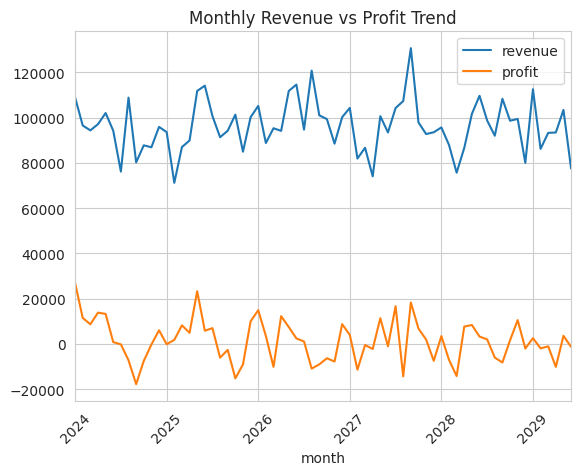

In [ ]:
df["month"] = df["order_date"].dt.to_period("M")

monthly = df.groupby("month")[["revenue","profit"]].sum().reset_index()

monthly.plot(x="month", y=["revenue","profit"], kind="line")
plt.xticks(rotation=45)
plt.title("Monthly Revenue vs Profit Trend")
plt.show()


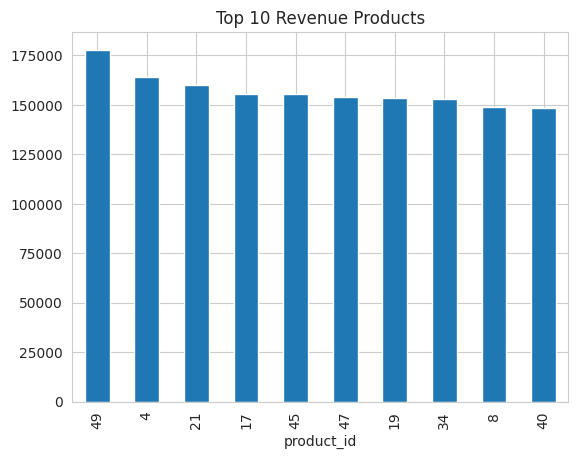

In [ ]:
top_products = df.groupby("product_id")["revenue"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Revenue Products")
plt.show()


In [ ]:
loss_products = df.groupby("product_id")["profit"].sum()
loss_products = loss_products[loss_products < 0]

loss_products.head()


,profit
product_id,
1,-39527
2,-13161
3,-22117
4,-48304
6,-48202


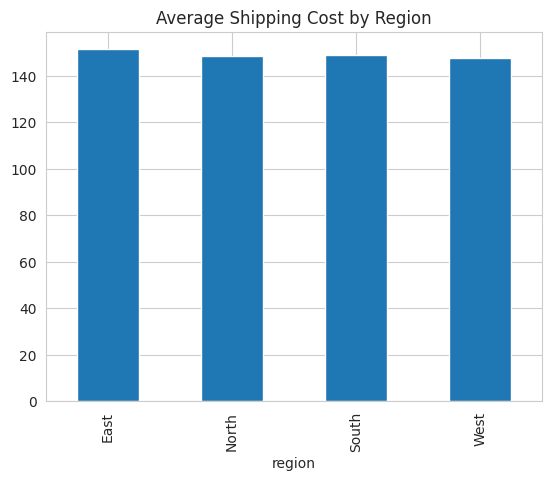

In [ ]:
region_shipping = df.groupby("region")["shipping_cost"].mean()

region_shipping.plot(kind="bar")
plt.title("Average Shipping Cost by Region")
plt.show()


In [ ]:
return_rate = df["return_flag"].value_counts(normalize=True) * 100
return_rate


,proportion
return_flag,
No,85.5
Yes,14.5


In [ ]:
df.groupby("month")[["discount","shipping_cost"]].mean()


,discount,shipping_cost
month,,
2024-01,158.387097,151.451613
2024-02,126.758621,156.206897
2024-03,160.032258,134.709677
2024-04,124.300000,153.433333
2024-05,161.645161,169.258065
...,...,...
2029-02,140.964286,153.357143
2029-03,114.483871,141.000000
2029-04,147.633333,145.366667


In [ ]:
monthly


,month,revenue,profit
0,2024-01,108850,26884
1,2024-02,96472,11467
2,2024-03,94324,8649
3,2024-04,97057,13811
4,2024-05,101980,13227
...,...,...,...
61,2029-02,86142,-1994
62,2029-03,93221,-1092
63,2029-04,93373,-10162
64,2029-05,103354,3553


In [ ]:
df.groupby("month")["return_loss"].sum()

,return_loss
month,
2024-01,4218
2024-02,13735
2024-03,7350
2024-04,13149
2024-05,622
...,...
2029-02,518
2029-03,15244
2029-04,14208


In [ ]:
df.groupby("month")["return_flag"].value_counts(normalize=True)


month    return_flag
2024-01  No             0.967742
         Yes            0.032258
2024-02  No             0.827586
         Yes            0.172414
2024-03  No             0.903226
                          ...   
2029-04  Yes            0.166667
2029-05  No             0.838710
         Yes            0.161290
2029-06  No             0.818182
         Yes            0.181818
Name: proportion, Length: 132, dtype: float64

In [ ]:
df.groupby("month")["margin_%"].mean()


,margin_%
month,
2024-01,5.800792
2024-02,-14.904004
2024-03,-5.565068
2024-04,-13.320724
2024-05,-3.932660
...,...
2029-02,-29.123642
2029-03,-29.674252
2029-04,-21.358770


Even though revenue might be increasing, profitability per order is shrinking badly.

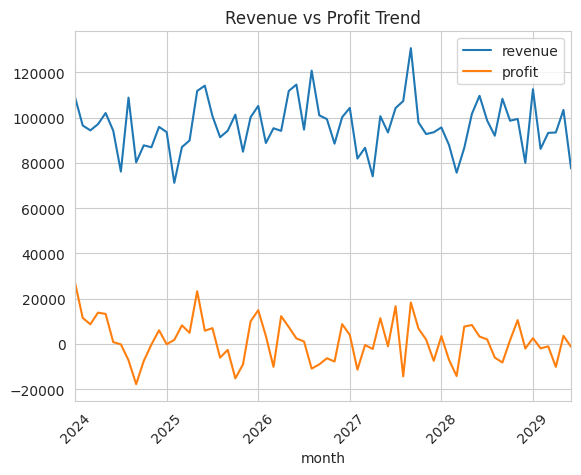

In [ ]:
monthly.plot(x="month", y=["revenue","profit"], kind="line")
plt.title("Revenue vs Profit Trend")
plt.xticks(rotation=45)
plt.show()


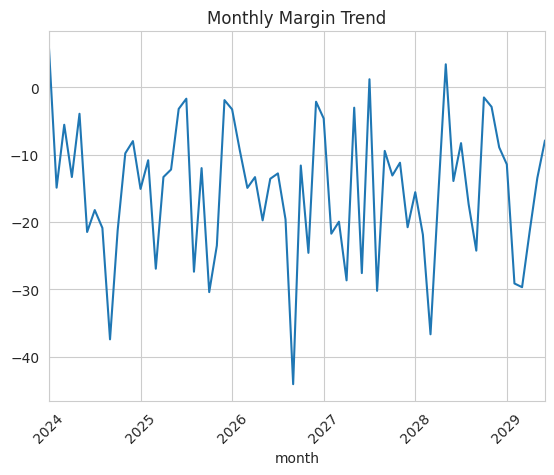

In [ ]:
df.groupby("month")["margin_%"].mean().plot()
plt.title("Monthly Margin Trend")
plt.xticks(rotation=45)
plt.show()


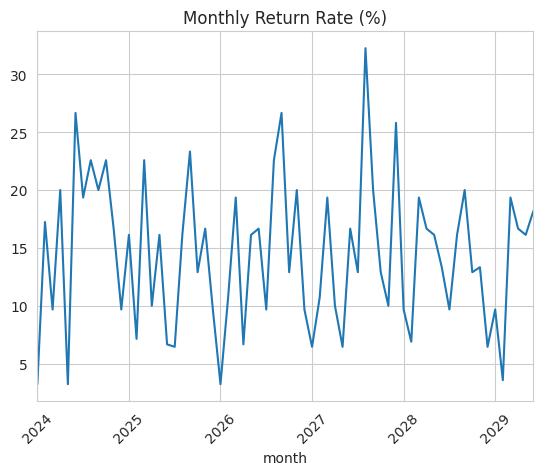

In [ ]:
return_trend = df.groupby("month")["return_flag"] \
                 .apply(lambda x: (x=="Yes").mean()*100)

return_trend.plot()
plt.title("Monthly Return Rate (%)")
plt.xticks(rotation=45)
plt.show()


Problem Statement

Over the past several months, the company has experienced consistent revenue growth.
However, despite this increase in sales, overall profit has been declining.
My objective was to identify the root causes behind declining profitability and provide data-driven business recommendations.

Data & Analysis Overview

I performed an end-to-end analysis using transactional order data, product cost data, shipping data, and return records.
The analysis included:
Revenue trend analysis
Cost structure breakdown
Discount impact evaluation
Shipping cost trend
Return rate analysis
Margin trend monitoring

Revenue vs Profit Trend

Line chart: Revenue ↑, Profit ↓

While revenue showed a steady upward trend month-over-month, profit margins declined significantly.
In some months, margins turned negative, indicating the company was selling at a loss.

Margin Collapse

Monthly Margin %

Margin dropped from +5.8% in January to as low as -29% in later months.
This indicates structural issues in cost and return management rather than revenue decline.

Return Rate Explosion

Return rate trend chart

Return rates increased sharply from approximately 3% to nearly 18% over time.
Since returned orders result in revenue loss but still incur product and shipping costs, this significantly impacted profitability

Average discount levels remained consistently high across months.
Aggressive discounting drove revenue growth but reduced contribution margin per order.
Revenue growth was volume-driven, not profitability-driven.

In [ ]:
!pip install dash plotly pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 55.4 MB/s eta 0:00:00


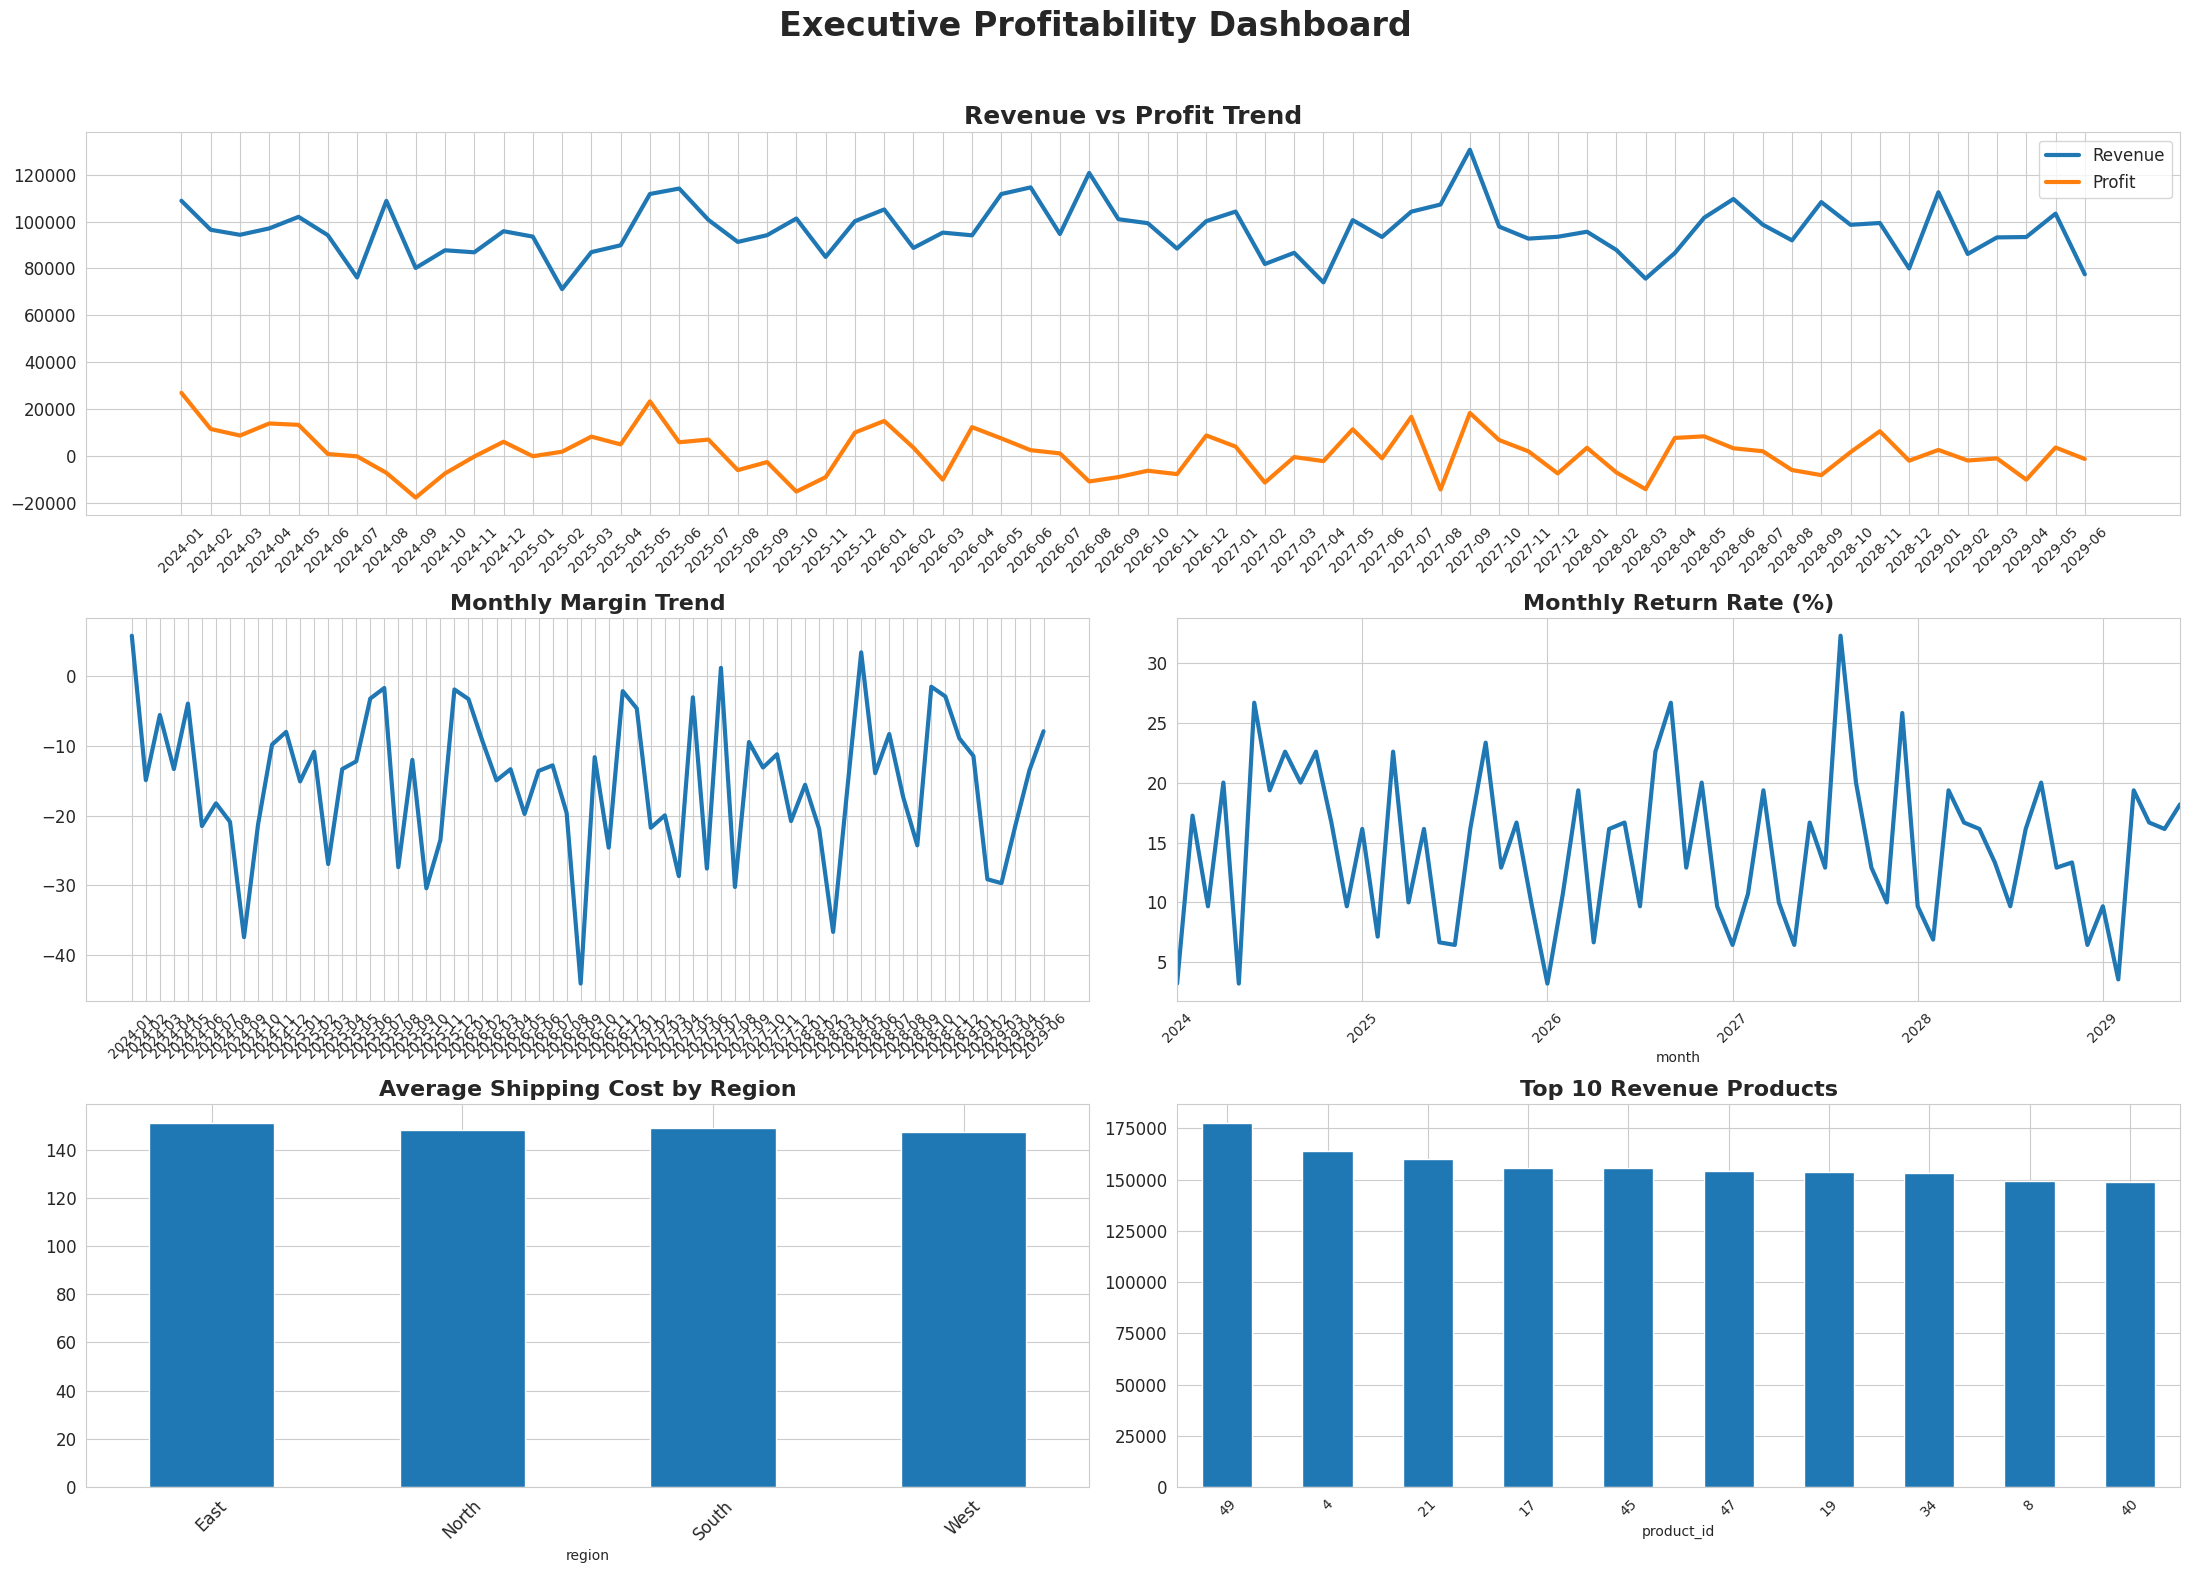

In [ ]:
import matplotlib.pyplot as plt

# Bigger figure
fig = plt.figure(figsize=(22, 16))

# Layout grid
gs = fig.add_gridspec(3, 2)

# Global title
fig.suptitle("Executive Profitability Dashboard",
             fontsize=24, fontweight="bold")

# -----------------------------
# 1️⃣ Revenue vs Profit Trend
# -----------------------------
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly["month"].astype(str), monthly["revenue"],
         linewidth=3, label="Revenue")
ax1.plot(monthly["month"].astype(str), monthly["profit"],
         linewidth=3, label="Profit")

ax1.set_title("Revenue vs Profit Trend",
              fontsize=18, fontweight="bold")
ax1.legend(fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.tick_params(axis='y', labelsize=12)

# -----------------------------
# 2️⃣ Monthly Margin Trend
# -----------------------------
ax2 = fig.add_subplot(gs[1, 0])
margin_trend = df.groupby("month")["margin_%"].mean()
ax2.plot(margin_trend.index.astype(str),
         margin_trend.values,
         linewidth=3)

ax2.set_title("Monthly Margin Trend",
              fontsize=16, fontweight="bold")
ax2.tick_params(axis='x', rotation=45, labelsize=10)
ax2.tick_params(axis='y', labelsize=12)

# -----------------------------
# 3️⃣ Monthly Return Rate
# -----------------------------
ax3 = fig.add_subplot(gs[1, 1])
return_trend.plot(ax=ax3, linewidth=3)

ax3.set_title("Monthly Return Rate (%)",
              fontsize=16, fontweight="bold")
ax3.tick_params(axis='x', rotation=45, labelsize=10)
ax3.tick_params(axis='y', labelsize=12)

# -----------------------------
# 4️⃣ Shipping Cost by Region
# -----------------------------
ax4 = fig.add_subplot(gs[2, 0])
region_shipping.plot(kind="bar", ax=ax4)

ax4.set_title("Average Shipping Cost by Region",
              fontsize=16, fontweight="bold")
ax4.tick_params(axis='x', rotation=45, labelsize=12)
ax4.tick_params(axis='y', labelsize=12)

# -----------------------------
# 5️⃣ Top Revenue Products
# -----------------------------
ax5 = fig.add_subplot(gs[2, 1])
top_products.plot(kind="bar", ax=ax5)

ax5.set_title("Top 10 Revenue Products",
              fontsize=16, fontweight="bold")
ax5.tick_params(axis='x', rotation=45, labelsize=10)
ax5.tick_params(axis='y', labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
avg_margin = df["margin_%"].mean()
avg_return = (df["return_flag"]=="Yes").mean()*100

print("========== EXECUTIVE SUMMARY ==========")
print(f"Total Revenue: {total_revenue:,.0f}")
print(f"Total Profit: {total_profit:,.0f}")
print(f"Average Margin: {avg_margin:.2f}%")
print(f"Average Return Rate: {avg_return:.2f}%")


========== EXECUTIVE SUMMARY ==========
Total Revenue: 6,348,480
Total Profit: 93,466
Average Margin: -15.17%
Average Return Rate: 14.50%


In [2]:
import matplotlib.pyplot as plt

plt.suptitle(
    "Executive Profitability Dashboard\nRoot Cause Analysis of Declining Profit Despite Revenue Growth",
    fontsize=18,
    fontweight='bold'
)

Text(0.5, 0.98, 'Executive Profitability Dashboard\nRoot Cause Analysis of Declining Profit Despite Revenue Growth')

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data generation (from cell G0PzDHvWcX-f)
np.random.seed(42)
n = 2000
orders = pd.DataFrame({
    "order_id": np.arange(1000, 1000+n),
    "order_date": pd.date_range(start="2024-01-01", periods=n, freq="D"),
    "customer_id": np.random.randint(1, 300, n),
    "product_id": np.random.randint(1, 50, n),
    "quantity": np.random.randint(1, 5, n),
    "selling_price": np.random.randint(500, 2000, n),
    "discount": np.random.randint(0, 300, n)
})
products = pd.DataFrame({
    "product_id": np.arange(1, 50),
    "cost_price": np.random.randint(300, 1500, 49)
})
customers = pd.DataFrame({
    "customer_id": np.arange(1, 300),
    "region": np.random.choice(["North","South","East","West"], 299)
})
shipping = pd.DataFrame({
    "order_id": orders["order_id"],
    "shipping_cost": np.random.randint(50, 250, n)
})
returns = pd.DataFrame({
    "order_id": orders["order_id"],
    "return_flag": np.random.choice(["Yes","No"], n, p=[0.15, 0.85])
})

# Create df by merging data (from cell ZW30vboTcdA5)
df = orders.merge(products, on="product_id", how="left") \
           .merge(customers, on="customer_id", how="left") \
           .merge(shipping, on="order_id", how="left") \
           .merge(returns, on="order_id", how="left")

# Data Cleaning & Preprocessing (from cells BNhd9QVLch2Q, PUD7jkVJckUU)
df = df[df["quantity"] > 0]
df["order_date"] = pd.to_datetime(df["order_date"])

# Feature Engineering (from cell is-65L_4cnhB)
df["revenue"] = df["quantity"] * df["selling_price"]
df["product_cost"] = df["quantity"] * df["cost_price"]
df["return_loss"] = np.where(df["return_flag"]=="Yes", df["revenue"], 0)
df["profit"] = (
    df["revenue"]
    - df["product_cost"]
    - df["discount"]
    - df["shipping_cost"]
    - df["return_loss"]
)
df["margin_%"] = (df["profit"] / df["revenue"]) * 100

# Retrieve the current figure
fig = plt.gcf()

# Calculate summary statistics
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
avg_margin = df["margin_%"].mean()
avg_return = (df["return_flag"]=="Yes").mean()*100

fig.text(
    0.10, 0.92,
    f"Revenue\n₹{total_revenue:,.0f}",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.35, 0.92,
    f"Profit\n₹{total_profit:,.0f}",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.60, 0.92,
    f"Avg Margin\n{avg_margin:.2f}%",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.85, 0.92,
    f"Return Rate\n{avg_return:.2f}%",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

Text(0.85, 0.92, 'Return Rate\n14.50%')

<Figure size 640x480 with 0 Axes>

In [9]:
fig.suptitle("Executive Profitability Dashboard", fontsize=22, fontweight="bold")

Text(0.5, 0.98, 'Executive Profitability Dashboard')

In [10]:
fig.text(
    0.10, 0.92,
    f"Revenue\n₹{total_revenue:,.0f}",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.35, 0.92,
    f"Profit\n₹{total_profit:,.0f}",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.60, 0.92,
    f"Avg Margin\n{avg_margin:.2f}%",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

fig.text(
    0.85, 0.92,
    f"Return Rate\n{avg_return:.2f}%",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

Text(0.85, 0.92, 'Return Rate\n14.50%')